# Overview

A minimal demo to use interpolation methods on time series data and apply a BERT language model on clinical notes for predicting mortality and length of stay (LOS) with the MIMIC-III dataset.

# Preprocessing the Time Series data

/tmp/ipykernel_23/804196307.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start='2024-09-01', periods=5, freq='H')


Original time series data with missing values:
                     heart_rate  blood_pressure
timestamp                                      
2024-09-01 00:00:00   79.967142      116.487946
2024-09-01 01:00:00   73.617357      143.688192
2024-09-01 02:00:00   81.476885      131.511521
2024-09-01 03:00:00   90.230299      112.957884
2024-09-01 04:00:00   72.658466      128.138401


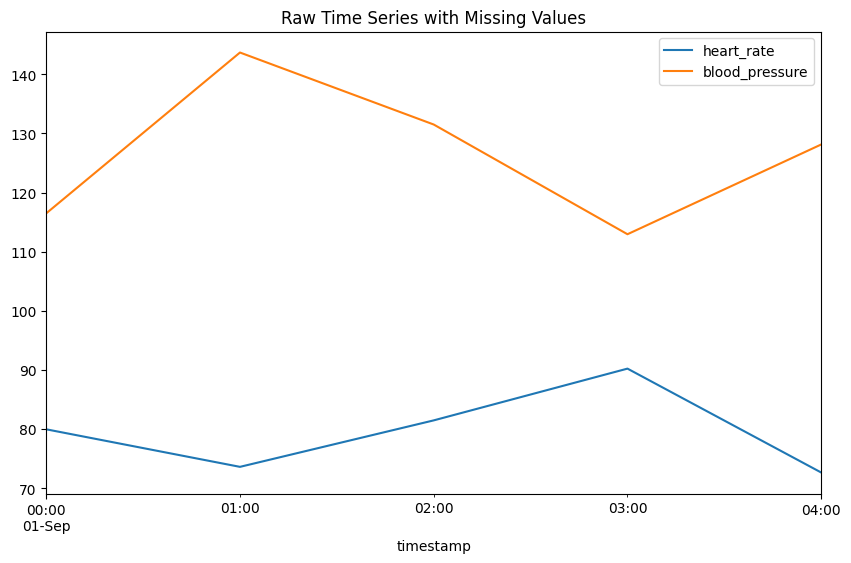

/tmp/ipykernel_23/804196307.py:38: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('1H').mean()



Interpolated time series data:
                     heart_rate  blood_pressure
timestamp                                      
2024-09-01 00:00:00   79.967142      116.487946
2024-09-01 01:00:00   73.617357      143.688192
2024-09-01 02:00:00   81.476885      131.511521
2024-09-01 03:00:00   90.230299      112.957884
2024-09-01 04:00:00   72.658466      128.138401


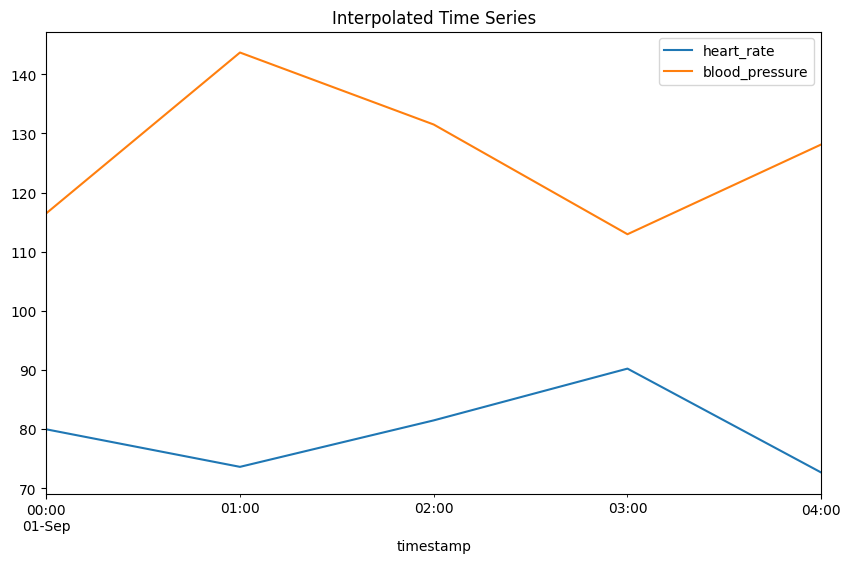

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate time series data for heart rate (HR) and blood pressure (BP)
np.random.seed(42)

# Generate time index for 48 hours with hourly data
time_index = pd.date_range(start='2024-09-01', periods=5, freq='H')

# Simulate random heart rate and blood pressure data with some missing values
heart_rate = np.random.normal(loc=75, scale=10, size=len(time_index))
blood_pressure = np.random.normal(loc=120, scale=15, size=len(time_index))

# Introduce some missing values (NaN)
heart_rate[10:15] = np.nan
blood_pressure[30:35] = np.nan

# Create a DataFrame
df = pd.DataFrame({
    'timestamp': time_index,
    'heart_rate': heart_rate,
    'blood_pressure': blood_pressure
})

# Set the timestamp as index
df.set_index('timestamp', inplace=True)

# Display the first few rows to visualize the raw data
print("Original time series data with missing values:")
print(df.head(10))

# Plot the time series with missing values
df.plot(y=['heart_rate', 'blood_pressure'], figsize=(10, 6), title="Raw Time Series with Missing Values")
plt.show()

# Resample the data to hourly intervals (this is already hourly in our case, but for generality)
df_resampled = df.resample('1H').mean()

# Apply linear interpolation to fill missing values
df_interpolated = df_resampled.interpolate(method='linear')

# Display the first few rows of the interpolated data
print("\nInterpolated time series data:")
print(df_interpolated.head(10))

# Plot the interpolated time series
df_interpolated.plot(y=['heart_rate', 'blood_pressure'], figsize=(10, 6), title="Interpolated Time Series")
plt.show()

In [2]:
# Example of engineered time series features from step 3
df_time_series = df_interpolated  # Assuming df_interpolated contains your engineered time series features

# Add a patient ID column to merge with the clinical notes embeddings later
df_time_series['patient_id'] = range(len(df_time_series))
df_time_series.head()

,heart_rate,blood_pressure,patient_id
timestamp,,,
2024-09-01 00:00:00,79.967142,116.487946,0
2024-09-01 01:00:00,73.617357,143.688192,1
2024-09-01 02:00:00,81.476885,131.511521,2
2024-09-01 03:00:00,90.230299,112.957884,3
2024-09-01 04:00:00,72.658466,128.138401,4


In [3]:
df_time_series.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5 entries, 2024-09-01 00:00:00 to 2024-09-01 04:00:00
Freq: h
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   heart_rate      5 non-null      float64
 1   blood_pressure  5 non-null      float64
 2   patient_id      5 non-null      int64  
dtypes: float64(2), int64(1)
memory usage: 160.0 bytes
